# Calculate mAP scores for bulk profiles of only failing cells comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
from copairs import map  # noqa: A004
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_density,
    ggplot,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from scipy.stats import mannwhitneyu, norm, wilcoxon
from tqdm import tqdm


## Helper functions

In [2]:
# Perform mean average precision calculation
def compute_activity_ap(
    treatment_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
) -> pd.DataFrame:
    """Compute per-profile average precision (AP) for one compound/dose group.

    Args:
        treatment_df (pd.DataFrame): Rows for a single compound/dose group plus
            the post-QC DMSO wells it should be compared against.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.

    Returns:
        pd.DataFrame: Per-profile AP scores (DMSO query rows dropped).
    """
    metadata = treatment_df.filter(regex="^Metadata")
    profiles = treatment_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    return activity_ap.query("Metadata_broad_sample != 'DMSO'")


def compute_map_scores(  # noqa: PLR0913
    df_activity: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    min_replicates: int,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mAP scores for every failing-cell compound/dose group vs. its own on-plate post-QC DMSO wells.

    Mirrors figure_5's ``compute_map_scores`` exactly (same-plate DMSO
    restriction per compound/dose group, and a single batched
    ``map.mean_average_precision`` call across every group so the FDR
    correction reflects the true number of tests) so that these failing-cell
    mAP scores are directly comparable ("apples to apples") to the pre-/
    post-QC mAP scores computed there. The only difference is the comparison
    pool: only-failing-cell profiles are compared against post-QC (passing)
    DMSO wells, and "DMSO_failing" rows (failing DMSO cells) are excluded
    entirely - they are never scored as a treatment nor used as reference.

    Args:
        df_activity (pd.DataFrame): Activity data (failing-cell treatment
            profiles + post-QC DMSO + DMSO_failing) with reference index
            assigned.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        min_replicates (int): Minimum replicate wells (and minimum distinct
            plates) required per compound/dose group for positive pairing.
        seed (int, optional): Random seed for the null distribution. Defaults to 0.

    Returns:
        pd.DataFrame: One row per compound/dose group with mAP scores, p-values,
            and average proportion of failed single cells.
    """
    non_dmso = df_activity[
        ~df_activity["Metadata_broad_sample"].isin(["DMSO", "DMSO_failing"])
    ]

    list_of_ap = []
    failed_prop_records = []
    for (treatment, dose), group_df in non_dmso.groupby(
        ["Metadata_broad_sample", "Metadata_dose_recode"]
    ):
        dose_plates = group_df["Metadata_Plate"].unique()
        unique_pos_diffby = group_df[pos_diffby].drop_duplicates()
        if (
            group_df.shape[0] < min_replicates
            or unique_pos_diffby.shape[0] < min_replicates
        ):
            print(
                f"Skipping {treatment} (dose {dose}): not enough replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue

        # Compare this compound/dose group only to post-QC DMSO wells from
        # the same plate(s) its own failing-cell replicates were run on
        treatment_df = df_activity[
            (
                (df_activity["Metadata_broad_sample"] == treatment)
                & (df_activity["Metadata_dose_recode"] == dose)
            )
            | (
                (df_activity["Metadata_broad_sample"] == "DMSO")
                & (df_activity["Metadata_Plate"].isin(dose_plates))
            )
        ]

        list_of_ap.append(
            compute_activity_ap(
                treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
            )
        )
        failed_prop_records.append(
            {
                "Metadata_broad_sample": treatment,
                "Metadata_dose_recode": dose,
                "Metadata_avg_prop_failed_single_cells": (
                    group_df["Metadata_sc_count_failed_qc"]
                    / group_df["Metadata_sc_count"]
                ).mean(),
            }
        )

    all_ap = pd.concat(list_of_ap, ignore_index=True)
    activity_map = map.mean_average_precision(
        all_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)

    return activity_map.merge(
        pd.DataFrame(failed_prop_records),
        on=["Metadata_broad_sample", "Metadata_dose_recode"],
        how="left",
    )


# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)


def calculate_replicate_cosine_similarity(
    activity_df: pd.DataFrame,
    group_cols: list[str] | None = None,
    exclude_profile_cols: list[str] | None = None,
    min_replicates: int = 2,
) -> pd.DataFrame:
    """Calculate pairwise replicate cosine similarity for all treatment groups.

    The returned rows are one compound-dose (or general group) each. The mean summarizes all
    pairwise cosine similarities among replicate profiles in that group.

    This function measures within-group reproducibility of feature profiles
    (e.g., compounds, doses, and DMSO controls) by computing cosine similarity
    between replicate feature vectors in a shared feature space.

    Args:
        activity_df (pd.DataFrame): DataFrame containing activity data with metadata and
            profile columns (feature space used for cosine similarity).
        group_cols (list[str], optional): List of metadata columns to group by. Defaults
            to ["Metadata_broad_sample", "Metadata_dose_recode"].
        exclude_profile_cols (list[str], optional): List of numeric columns to exclude
            from profile data (e.g., "failed_proportion").
            Defaults to ["failed_proportion"].
        min_replicates (int, optional): Minimum number of replicates required to
            calculate cosine similarity. Defaults to 2.

    Returns:
        pd.DataFrame: DataFrame with group columns and summary statistics of
            pairwise cosine similarity for each treatment group.
    """
    # Set default columns if not provided
    if group_cols is None:
        group_cols = ["Metadata_broad_sample", "Metadata_dose_recode"]
    if exclude_profile_cols is None:
        exclude_profile_cols = ["failed_proportion"]

    # Use full dataset (no external filtering / map restriction)
    activity_subset = activity_df.copy()

    # Identify profile columns by excluding metadata and specified columns
    metadata_cols = activity_subset.filter(regex="^Metadata").columns
    numeric_cols = activity_subset.select_dtypes(include="number").columns
    profile_cols = [
        col
        for col in numeric_cols
        if col not in metadata_cols and col not in exclude_profile_cols
    ]

    # Calculate pairwise cosine similarity for each group and store results
    results = []
    for group_values, group_df in activity_subset.groupby(group_cols, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        # Extract profile data and handle NaN values by replacing them with zeros
        profiles = group_df[profile_cols].to_numpy(dtype=float)
        profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)

        # Skip groups with fewer than the minimum number of replicates
        if profiles.shape[0] < min_replicates:
            continue

        # Ensure proper cosine similarity even if upstream normalization drifted
        norms = np.linalg.norm(profiles, axis=1, keepdims=True)
        profiles = np.divide(
            profiles, norms, out=np.zeros_like(profiles), where=norms != 0
        )

        cosine_matrix = profiles @ profiles.T

        # Extract upper triangle (excluding diagonal)
        pair_indices = np.triu_indices(profiles.shape[0], k=1)
        pairwise_cosine = cosine_matrix[pair_indices]

        # Store results with group values and summary statistics
        results.append(
            {
                **dict(zip(group_cols, group_values, strict=True)),
                "n_replicates": profiles.shape[0],
                "n_pairwise_comparisons": pairwise_cosine.size,
                "mean_pairwise_cosine_similarity": pairwise_cosine.mean(),
                "median_pairwise_cosine_similarity": np.median(pairwise_cosine),
                "std_pairwise_cosine_similarity": (
                    pairwise_cosine.std(ddof=1) if pairwise_cosine.size > 1 else 0.0
                ),
            }
        )

    return pd.DataFrame(results)


## Load in the data for post QC and only failing QC cells

In [3]:
MIN_REPLICATES = 2

input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

post_qc_file = pathlib.Path(
    input_dir,
    "whole_batch_post_qc_cpd_replicates.parquet",
)
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

failing_qc_file = pathlib.Path(
    input_dir,
    "whole_batch_post_qc_cpd_replicates_only_failing_cells.parquet",
)
failing_qc_df = pd.read_parquet(failing_qc_file)
failing_qc_df = failing_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
failing_qc_df["Metadata_sc_count_failed_qc"] = failing_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

failing_qc_df.loc[
    failing_qc_df["Metadata_broad_sample"] == "DMSO",
    "Metadata_broad_sample",
] = "DMSO_failing"

post_dmso_df = post_qc_df[post_qc_df["Metadata_broad_sample"] == "DMSO"].copy()

meta_cols = [c for c in post_dmso_df.columns if c.startswith("Metadata_")]

post_features = set(post_dmso_df.columns) - set(meta_cols)
failing_features = set(failing_qc_df.columns) - set(meta_cols)

shared_features = list(post_features & failing_features)
shared_meta = list(
    set(meta_cols) & set(failing_qc_df.columns) & set(post_dmso_df.columns)
)

post_dmso_df = pd.concat(
    [post_dmso_df[shared_meta], post_dmso_df[shared_features]],
    axis=1,
)

failing_qc_df = pd.concat(
    [failing_qc_df[shared_meta], failing_qc_df[shared_features]],
    axis=1,
)

map_df = pd.concat(
    [post_dmso_df, failing_qc_df],
    ignore_index=True,
)

print(f"Post-QC DMSO profiles: {len(post_dmso_df):,}")
print(f"Failing-cell profiles: {len(failing_qc_df):,}")
print(f"Combined profiles: {len(map_df):,}")


Post-QC DMSO profiles: 3,264
Failing-cell profiles: 51,828
Combined profiles: 55,092


In [4]:
print(map_df.shape)
map_df.head()


(55092, 802)


,Metadata_sc_count,Metadata_Well,Metadata_broad_id,Metadata_dose_recode,Metadata_moa,Metadata_sc_count_failed_qc,Metadata_sc_count_passed_qc,Metadata_pert_id,Metadata_Plate,Metadata_broad_sample,...,Nuclei_Intensity_IntegratedIntensity_RNA,Nuclei_Correlation_Overlap_DNA_ER,Cytoplasm_Correlation_K_ER_DNA,Cytoplasm_Texture_Correlation_AGP_20_0,Cells_Correlation_Overlap_Mito_ER,Cells_Texture_InfoMeas2_Mito_5_0,Nuclei_Texture_InverseDifferenceMoment_RNA_5_0,Cytoplasm_Texture_Correlation_AGP_5_0,Cytoplasm_RadialDistribution_RadialCV_AGP_1of4,Nuclei_RadialDistribution_MeanFrac_ER_1of4
0,2050,A01,None,0,None,845.0,1205.0,None,SQ00014812,DMSO,...,-0.920633,-0.755262,-0.419371,0.032527,-0.207873,1.007232,-0.269489,-0.790031,0.095599,0.560962
1,2276,A02,None,0,None,666.0,1610.0,None,SQ00014812,DMSO,...,0.992934,0.090590,-0.618461,-0.711541,0.263786,1.169090,-1.008338,-0.732124,-0.156266,0.060462
2,2634,A03,None,0,None,823.0,1811.0,None,SQ00014812,DMSO,...,-0.233028,0.340687,-0.200817,-1.319504,-0.711185,-0.441168,0.883380,0.784938,0.717223,0.542870
3,2807,A04,None,0,None,814.0,1993.0,None,SQ00014812,DMSO,...,-0.613619,0.711406,-0.565786,1.087003,-0.476907,0.473831,1.301626,0.487227,-0.732293,1.821172
4,2928,A05,None,0,None,556.0,2372.0,None,SQ00014812,DMSO,...,-1.125119,-0.872607,-1.279126,-2.367596,-0.083375,-0.245115,-0.367832,0.338407,-0.015829,-0.162178


## Assign reference index

In [5]:
reference_col = "Metadata_reference_index"

map_df_activity = assign_reference_index(
    map_df,
    "Metadata_broad_sample == 'DMSO'",  # ONLY post-QC DMSO matches this now
    reference_col=reference_col,
    default_value=-1,
)


## Set positive and negative pairs for compounds

In [6]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]


## Calculate mAP scores for failing cells per treatment compared to post-QC controls

In [7]:
postqc_map_file = f"{output_dir}/final_map_scores_failing_vs_postQC_controls.parquet"

if os.path.exists(postqc_map_file):
    final_map_postQC = pd.read_parquet(postqc_map_file)
    print("Loaded failing-vs-postQC mAP results from file.")

else:
    final_map_postQC = compute_map_scores(
        map_df_activity,
        pos_sameby,
        pos_diffby,
        neg_sameby,
        neg_diffby,
        MIN_REPLICATES,
    )
    final_map_postQC["QC_status"] = "failing_vs_postQC_controls"

    # save
    final_map_postQC.to_parquet(postqc_map_file, index=False)


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/copairs/compute.py:50: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9325 [00:00<?, ?it/s]

In [8]:
final_map_postQC.head()


,Metadata_broad_sample,Metadata_dose_recode,Metadata_reference_index,mean_average_precision,indices,mean_normalized_average_precision,p_value,corrected_p_value,below_p,below_corrected_p,-log10(p-value),Metadata_avg_prop_failed_single_cells,QC_status
0,BRD-A00147595-001-01-5,1,-1,0.485817,"[0, 1, 2, 3]",0.446140,0.002400,0.002509,True,True,2.600451,0.246434,failing_vs_postQC_controls
1,BRD-A00147595-001-01-5,2,-1,0.512767,"[4, 5, 6, 7]",0.475170,0.001900,0.002015,True,True,2.695630,0.283612,failing_vs_postQC_controls
2,BRD-A00147595-001-01-5,3,-1,0.296345,"[8, 9, 10, 11]",0.242047,0.037296,0.037914,True,True,1.421197,0.284254,failing_vs_postQC_controls
3,BRD-A00147595-001-01-5,4,-1,0.514667,"[12, 13, 14, 15]",0.477216,0.001900,0.002015,True,True,2.695630,0.272083,failing_vs_postQC_controls
4,BRD-A00147595-001-01-5,5,-1,0.918561,"[16, 17, 18, 19]",0.912276,0.000100,0.000115,True,True,3.940806,0.259502,failing_vs_postQC_controls


In [9]:
# Load in mAP scores only passing cells
pre_QC_map = pd.read_parquet("../figure_5/mAP_results/final_map_scores_preQC.parquet")
passing_post_QC_map = pd.read_parquet(
    "../figure_5/mAP_results/final_map_scores_postQC.parquet"
)

# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    pre_QC_map,
    passing_post_QC_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

# Compute change per row
merged_map["mAP_change"] = (
    merged_map["mean_average_precision_postQC"]
    - merged_map["mean_average_precision_preQC"]
)

# Label direction of change
merged_map["mAP_trend"] = np.select(
    [
        merged_map["mAP_change"] > 0,
        merged_map["mAP_change"] < 0,
    ],
    [
        "increase",
        "decrease",
    ],
    default="no_change",
)

# Keep only trend mapping
trend_map = merged_map[["Metadata_broad_sample", "Metadata_dose_recode", "mAP_trend"]]

# Merge into final post-QC dataframe
final_map_postQC_trend = final_map_postQC.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)


QC_state            mAP_trend
Only failing cells  Decreased    4849
                    Increased    3424
Only passing cells  Decreased    4849
                    Increased    3424
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8.5 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./figures/only_failing_vs_passing_mAP_scores_dist_by_trend.png


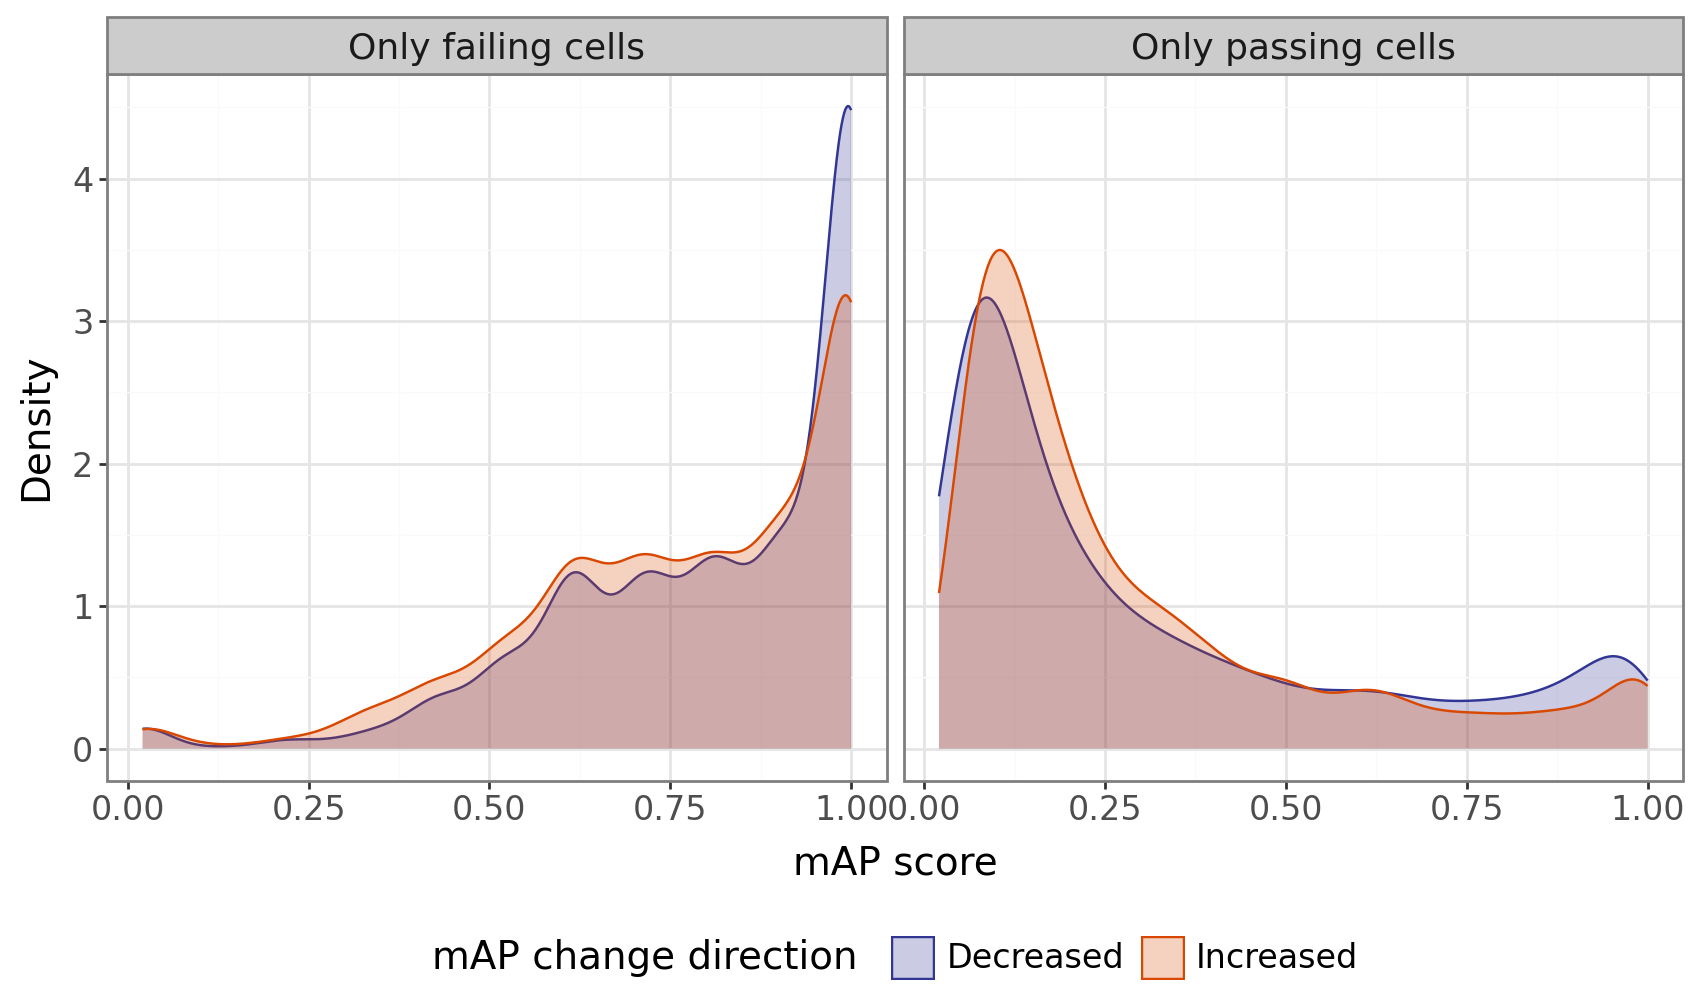

In [10]:
# -----------------------------
# 1. Merge trend_map into BOTH QC datasets (failing_QC already has it, but redo for consistency)
# -----------------------------
final_map_postQC_trend_labeled = final_map_postQC.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)
post_qc_labeled = passing_post_QC_map.merge(
    trend_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)

# -----------------------------
# 2. Drop rows with no change or missing trend
# -----------------------------
final_map_postQC_trend_labeled = final_map_postQC_trend_labeled[
    final_map_postQC_trend_labeled["mAP_trend"].isin(["increase", "decrease"])
]
post_qc_labeled = post_qc_labeled[
    post_qc_labeled["mAP_trend"].isin(["increase", "decrease"])
]

# -----------------------------
# 3. Add QC labels
# -----------------------------
final_map_postQC_trend_labeled["QC_state"] = "failed_QC_cells"
post_qc_labeled["QC_state"] = "passed_QC_cells"

# -----------------------------
# 4. Combine
# -----------------------------
plot_df = pd.concat(
    [final_map_postQC_trend_labeled, post_qc_labeled], ignore_index=True
)

# -----------------------------
# 5. Standardize labels for plotting
# -----------------------------
plot_df["QC_state"] = plot_df["QC_state"].replace(
    {
        "failed_QC_cells": "Only failing cells",
        "passed_QC_cells": "Only passing cells",
    }
)
plot_df["mAP_trend"] = plot_df["mAP_trend"].replace(
    {"increase": "Increased", "decrease": "Decreased"}
)

# Diagnostic — confirm both trends are present in each QC state
print(plot_df.groupby("QC_state")["mAP_trend"].value_counts(dropna=False))

# -----------------------------
# 6. Density plot (KDE curves), faceted by QC state, colored by trend
# -----------------------------
p = (
    ggplot(
        plot_df,
        aes(
            x="mean_average_precision",
            color="mAP_trend",
            fill="mAP_trend",
        ),
    )
    + geom_density(alpha=0.25)
    + facet_wrap("~QC_state")
    + scale_color_manual(values={"Decreased": "#313695", "Increased": "#d94801"})
    + scale_fill_manual(values={"Decreased": "#313695", "Increased": "#d94801"})
    + theme_bw()
    + theme(
        figure_size=(8.5, 5),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
        strip_text=element_text(size=13),
        legend_position="bottom",
    )
    + labs(
        x="mAP score",
        y="Density",
        color="mAP change direction",
        fill="mAP change direction",
    )
)
p.save("./figures/only_failing_vs_passing_mAP_scores_dist_by_trend.png", dpi=600)
p.show()


In [11]:
# Build an explicit paired table: one row per compound+dose condition, with
# both the "only failing cells" and "only passing cells" mAP scores as
# separate columns. `failed` and `passed` below come straight out of this
# merge (rather than being independently re-filtered from `plot_df`), so
# `failed[i]` and `passed[i]` are guaranteed to refer to the same
# compound+dose -- this matters once we treat the two mAP scores as a
# matched pair rather than two unrelated samples (see the next cell).
paired_map = final_map_postQC_trend_labeled.merge(
    post_qc_labeled,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_failed", "_passed"),
)

failed = paired_map["mean_average_precision_failed"]
passed = paired_map["mean_average_precision_passed"]

print(f"n paired compound+dose conditions: {len(paired_map)}")
print(f"median: failed={failed.median():.4f}, passed={passed.median():.4f}")
print(f"mean:   failed={failed.mean():.4f}, passed={passed.mean():.4f}")


n paired compound+dose conditions: 8273
median: failed=0.8489, passed=0.1853
mean:   failed=0.7976, passed=0.3046
